## Evaluation of the Neural Additive Model (NAM) on OpenML Dataset

This notebook evaluates trained NAM models on OpenML datasets.


In [11]:
# ============================================================================
# CONFIGURATION
# ============================================================================
OPENML_DATASET_ID = 44966  # OpenML dataset ID
TASK_TYPE = "regression"  # Options: "classification" or "regression"
NUM_FOLDS = 5  # Number of folds for cross-validation
NUM_SPLITS = 20  # Number of splits per fold


In [12]:
import sys
from pathlib import Path

# Add src to path for imports
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder
import numpy as np
from utils import load_col_min_max, inverse_min_max_scaler


In [ ]:
# Load dataset
dataset_name = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
is_regression = (TASK_TYPE == "regression")

print(f"Loading dataset: {dataset_name}")
data = data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data

print(f"Dataset shape: {data_x.shape}")
print(f"Target shape: {data_y.shape}")
print(f"Number of features: {data_x.shape[1]}")
print(f"Task type: {'Regression' if is_regression else 'Classification'}")

col_min_max = load_col_min_max(dataset_name)



Loading dataset: OpenML_44966_regression
Dataset shape: (1066, 29)
Target shape: (1066,)
Number of features: 29
Task type: Regression
Computing col_min_max for OpenML_44966_regression...
Computed col_min_max for 29 features


In [14]:
from utils import create_fold_indices

fold_train_indices, fold_test_indices = create_fold_indices(
    data_x,
    data_y,
    num_folds=NUM_FOLDS,
    is_regression=is_regression,
    random_state=42
)


In [ ]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
try:
    COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)
except:
    # Use column names as-is if no config available
    COL_NAMES = {dataset_name: {name: name for name in column_names}}
    FEATURE_LABEL_MAPPING = {dataset_name: {name: name for name in column_names}}
    CATEGORICAL_NAMES = []


In [16]:
from utils import gather_nam_predictions_and_hist_data

# Set results directory
project_root = Path.cwd().parent.parent
base_logdir = project_root / 'results' / 'training' / 'nam' / f'openml_{OPENML_DATASET_ID}_{TASK_TYPE}'

all_preds_per_fold, all_hist_data, all_mean_pred = gather_nam_predictions_and_hist_data(
    fold_test_indices=fold_test_indices,
    data_x=data_x,
    column_names=column_names,
    unique_features=UNIQUE_FEATURES,
    dataset_name=dataset_name,
    base_logdir=str(base_logdir),
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    print_every=5
)


Processing fold 1 (test set size: 214)...
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_44966_regression/fold_1/split_1/model_0/best_checkpoint\model.ckpt-970
Feature widths: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 2]
Num input features: 29
Auto-detected shallow=False from checkpoint structure
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_44966_regression/fold_1/split_1/model_0/best_checkpoint\model.ckpt-970
✅ Restored NAM from checkpoint.
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_44966_regression/fold_1/split_2/model_0/best_checkpoint\model.ckpt-330
Feature widths: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 2]
Num input features: 29
Auto-detected s

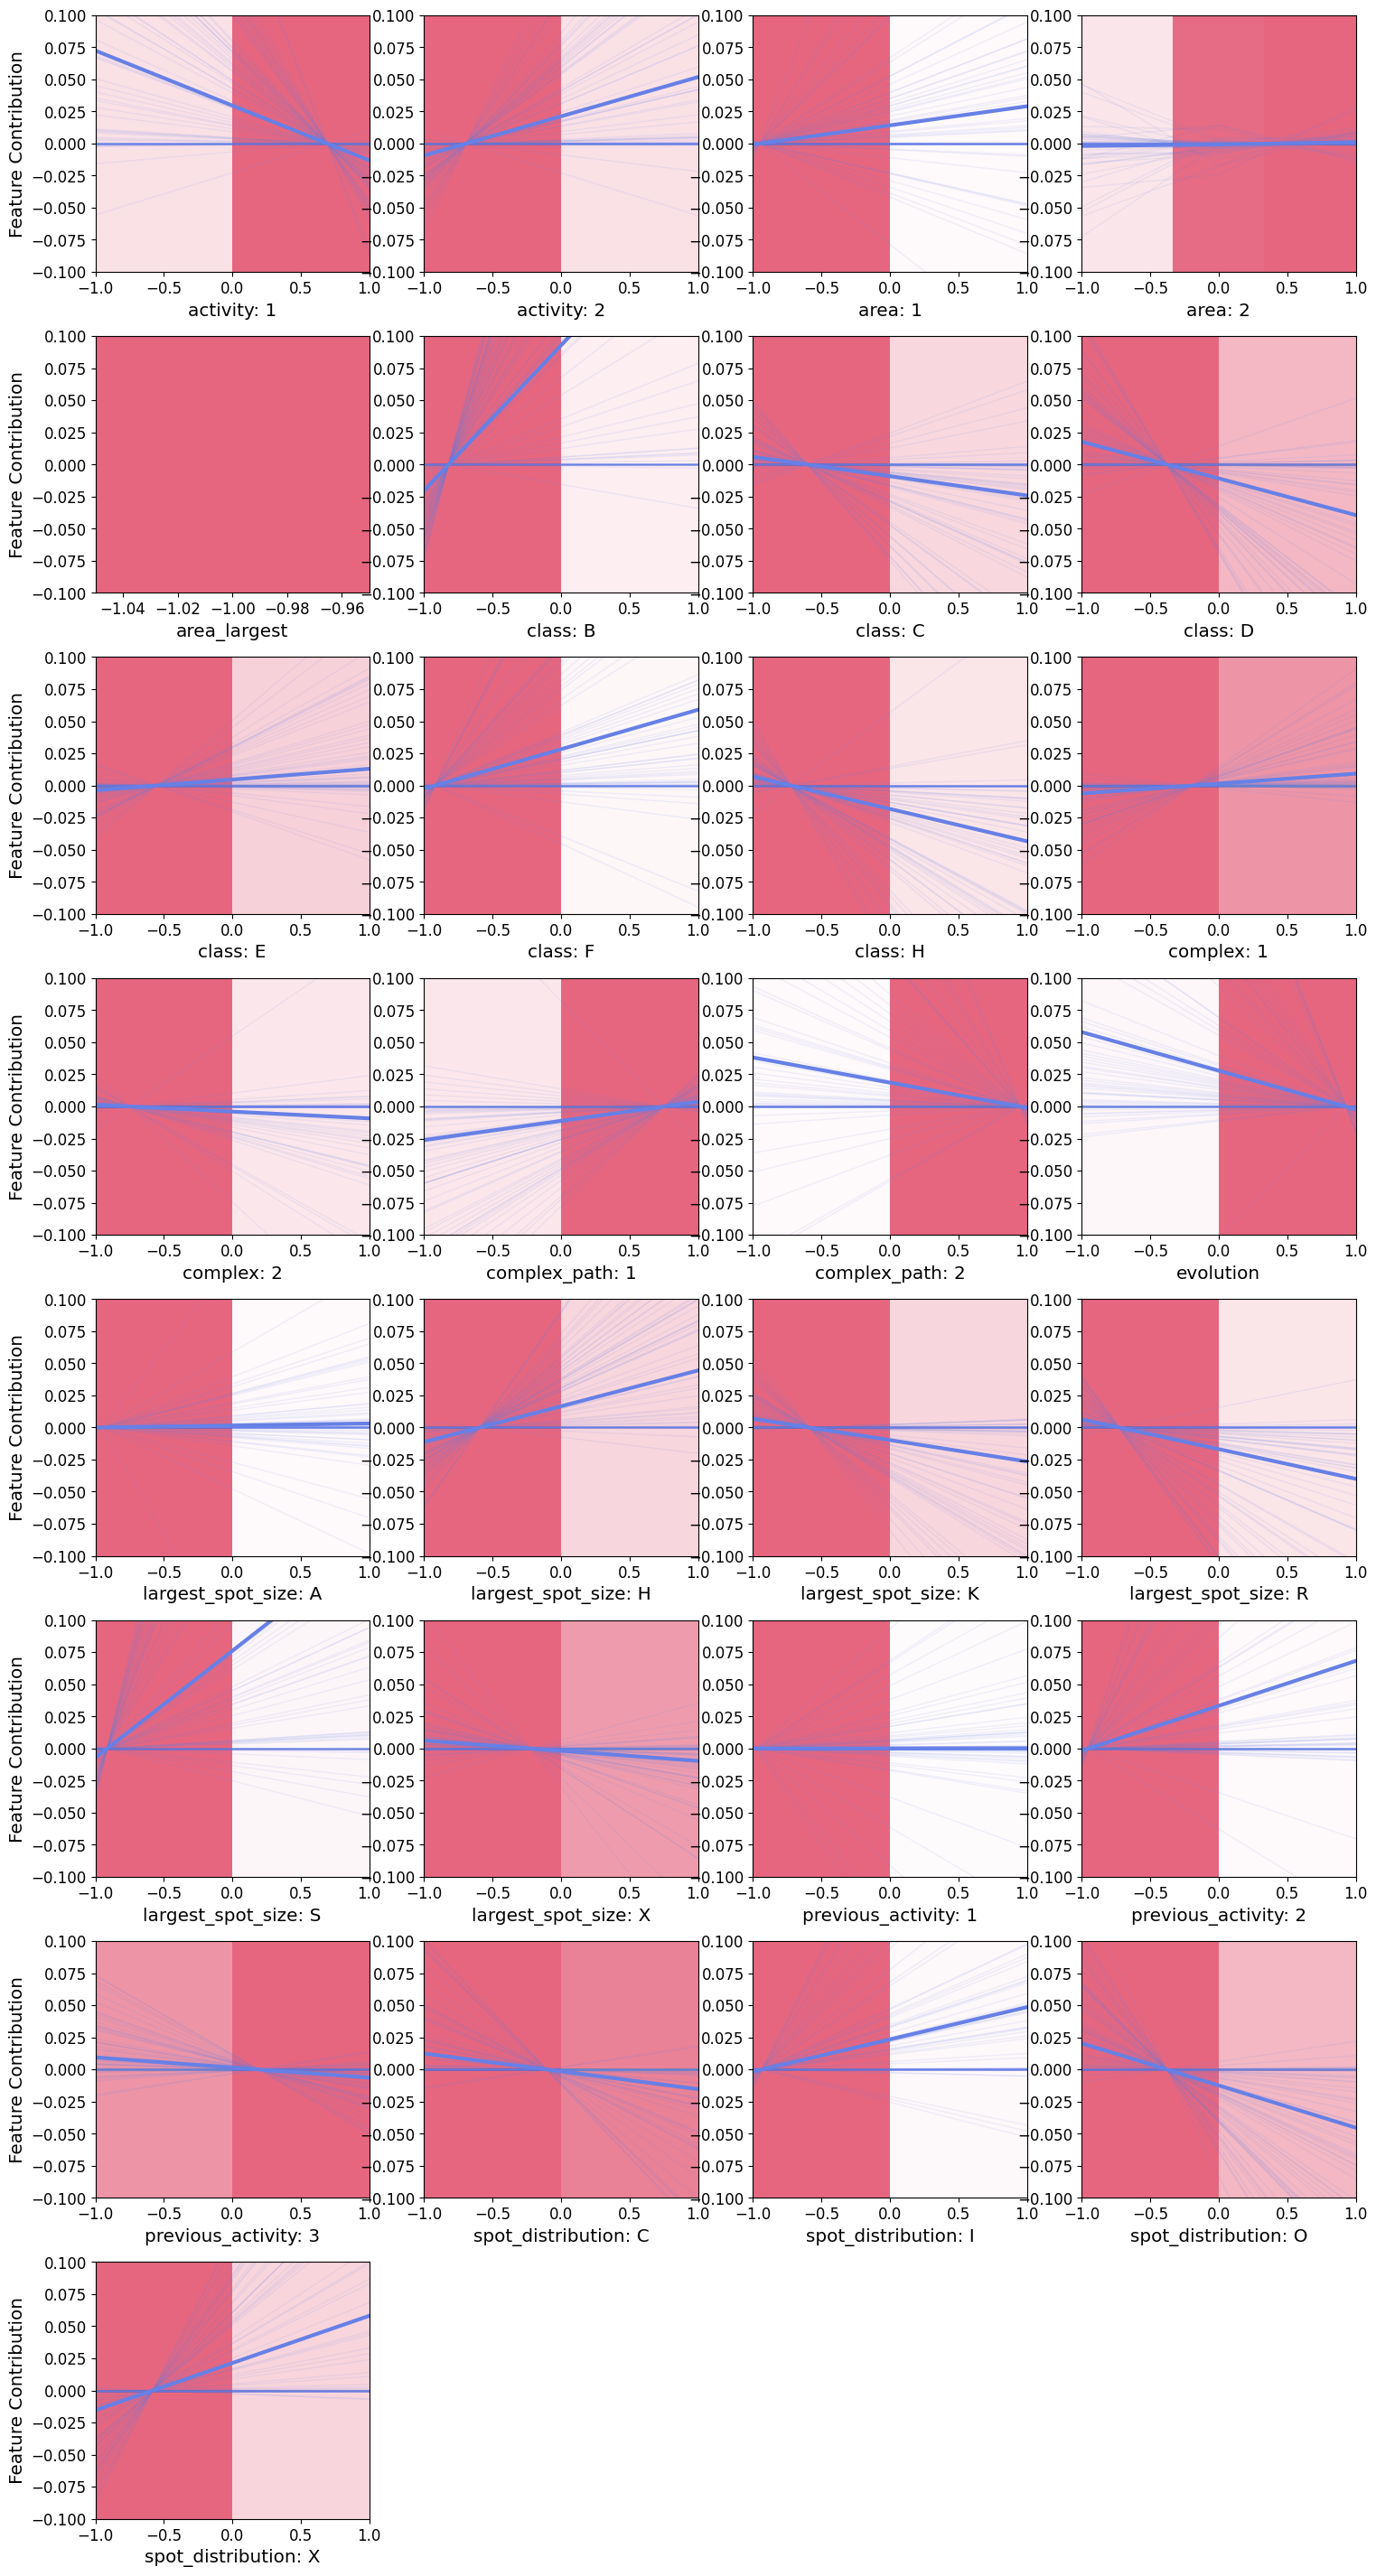

In [23]:
from utils import plot_nam_contributions_with_density

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    y_limits=(-0.1, 0.1)
)


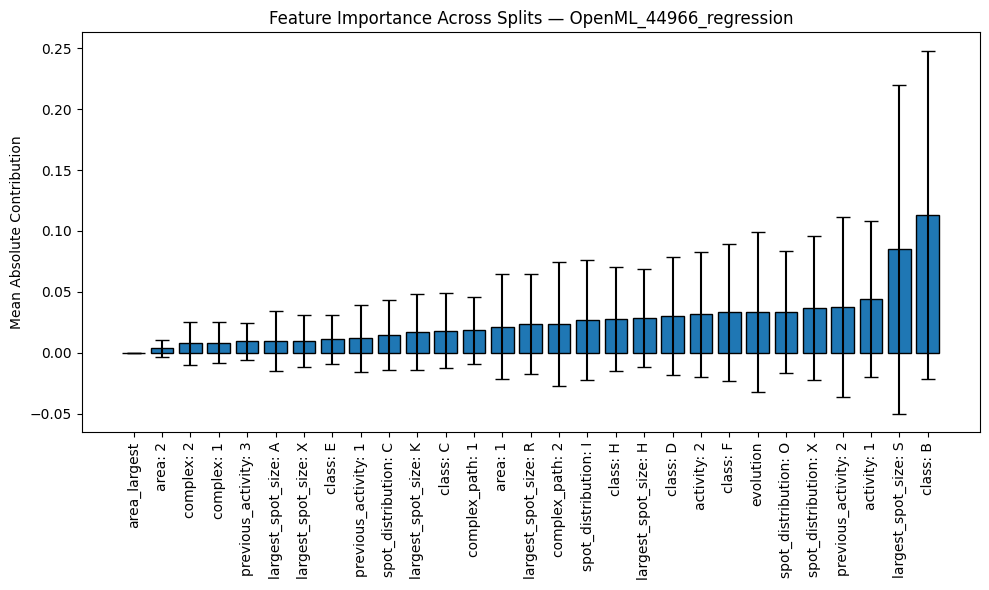

In [18]:
from utils import plot_feature_importance_across_splits

sorted_features, sorted_mean, sorted_std = plot_feature_importance_across_splits(
    all_hist_data,
    all_mean_pred,
    dataset_name
)

In [19]:
from utils import evaluate_ensemble_across_folds

fold_rmses, avg_rmse, std_rmse = evaluate_ensemble_across_folds(
    all_preds_per_fold,
    fold_test_indices,
    data_y,
    is_regression=True,
    verbose=True
)

Fold 1 RMSE (test set only): 0.8067 (n=214)
Fold 2 RMSE (test set only): 0.7514 (n=213)
Fold 3 RMSE (test set only): 0.8597 (n=213)
Fold 4 RMSE (test set only): 0.7394 (n=213)
Fold 5 RMSE (test set only): 0.6932 (n=213)

Average Ensemble RMSE across folds (test sets only): 0.7701
Std of Ensemble RMSE across folds: 0.0576
